<a href="https://colab.research.google.com/github/enessbulut/YOLOv8/blob/main/object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/YOLOv8/1_object_detection

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/YOLOv8/1_object_detection


In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.0/112.6 GB disk)


In [ ]:
!unzip /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset.zip \
-d /content/drive/MyDrive/YOLOv8/1_object_detection/data


Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/3207.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/3208.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/321.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/3210.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/3211.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/3212.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/3213.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data/brain_tumor_dataset/images/train/3214.jpg  
  inflating: /content/drive/MyDrive/YOLOv8/1_object_detection/data

In [ ]:
!yolo detect train data=data/config.yaml model=yolov8n.pt epochs=100 imgsz=640 workers=8 batch=8 device=0 name=yolov8_brain_tumor_detection

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_brain_tumor_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

In [ ]:
!yolo detect predict model=/content/drive/MyDrive/YOLOv8/1_object_detection/runs/detect/yolov8_brain_tumor_detection/weights/best.pt source=inference save= True

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference/101.jpg: 640x640 (no detections), 13.3ms
image 2/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference/1025.jpg: 640x512 (no detections), 65.4ms
image 3/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference/1034.jpg: 640x544 2 Tumors, 66.0ms
image 4/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference/1049.jpg: 640x608 2 Tumors, 140.2ms
image 5/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference/1057.jpg: 640x640 (no detections), 8.0ms
image 6/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference/1058.jpg: 640x640 (no detections), 7.2ms
image 7/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference/1067.jpg: 640x480 1 Tumor, 35.7ms
image 8/367 /content/drive/MyDrive/YOLOv8/1_object_detection/inference


image 1/1 /content/drive/MyDrive/YOLOv8/1_object_detection/runs/detect/32.jpg: 416x640 1 Tumor, 55.4ms
Speed: 2.6ms preprocess, 55.4ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 640)


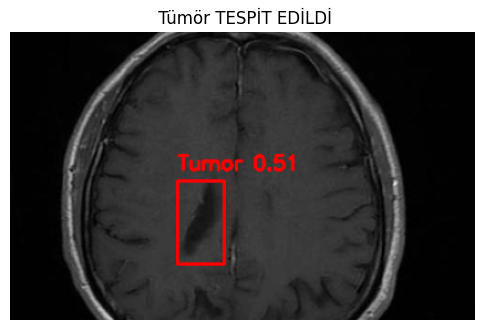

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1️ MODEL ve RESİM YOLU
MODEL_PATH = "/content/drive/MyDrive/YOLOv8/1_object_detection/runs/detect/yolov8_brain_tumor_detection/weights/best.pt"
IMAGE_PATH = "/content/drive/MyDrive/YOLOv8/1_object_detection/runs/detect/32.jpg"

# 2️ Modeli yükle
model = YOLO(MODEL_PATH)

# 3️ Tahmin yap
results = model.predict(
    source=IMAGE_PATH,
    imgsz=640,
    conf=0.25,
    save=False
)

# 4️ Orijinal resmi oku
img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 5️ Bounding box çiz
tumor_found = False

for r in results:
    if r.boxes is not None:
        for box in r.boxes:
            tumor_found = True

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])

            # Dikdörtgen çiz
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

            # Confidence yaz
            label = f"Tumor {conf:.2f}"
            cv2.putText(
                img,
                label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

# 6️ Kullanıcıya göster
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")

if tumor_found:
    plt.title(" Tümör TESPİT EDİLDİ")
else:
    plt.title(" Tümör YOK")

plt.show()
